# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [1]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [2]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.utils import PyDataset

def get_stl10_memmap():

    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )
    base_dir = os.path.dirname(path)
    filepath = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin')

    shape = (100000, 3, 96, 96)
    images_mmap = np.memmap(filepath, dtype='uint8', mode='r', shape=shape)

    return images_mmap

class PatchGenerator(PyDataset):
    def __init__(self, images_mmap, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        # Store the pointer to the memmap, keep it as uint8
        self.images = images_mmap
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            # 1. Load from disk/cache only what we need
            # 2. Transpose from (C, H, W) to (H, W, C)
            # 3. Convert to float and normalize ONLY this one image
            img_cxhxw = self.images[img_idx]
            full_img = img_cxhxw.transpose(1, 2, 0).astype("float32") / 255.0

            Y[i] = full_img

            # Patch extraction logic
            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_s:y_s+self.patch_size, x_s:x_s+self.patch_size, :]

                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin:margin+self.crop_size, margin:margin+self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [3]:
# Trigger the download and loading
images = get_stl10_memmap()
print(f"Successfully loaded {images.shape[0]} images.")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 260s 0us/step
Successfully loaded 100000 images.


In [4]:
print(images.shape)

(100000, 3, 96, 96)


In [5]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [6]:
# train_generator = PatchGenerator(images, batch_size=8)
# val_generator = PatchGenerator(val_images, batch_size=8)
# test_generator = PatchGenerator(test_images, batch_size=8)

##small portion of data for testing the code (comment out later)

In [7]:
# # ── SMOKE TEST: use a tiny slice of data ──────────────────────────────────
# # Change these numbers to scale up later
# N_TRAIN = 500
# N_VAL   = 100
# N_TEST  = 100

# train_images_small = train_images[:N_TRAIN]
# val_images_small   = val_images[:N_VAL]
# test_images_small  = test_images[:N_TEST]

# # Override generators with small versions
# train_gen = PatchGenerator(train_images_small, batch_size=32, shuffle=True)
# val_gen   = PatchGenerator(val_images_small,   batch_size=32, shuffle=False)
# test_gen  = PatchGenerator(test_images_small,  batch_size=32, shuffle=False)

# print(f"Train batches : {len(train_gen)}   ({N_TRAIN} images)")
# print(f"Val batches   : {len(val_gen)}     ({N_VAL} images)")
# print(f"Test batches  : {len(test_gen)}    ({N_TEST} images)")
train_gen = PatchGenerator(train_images, batch_size=64, shuffle=True)
val_gen   = PatchGenerator(val_images,   batch_size=64, shuffle=False)
test_gen  = PatchGenerator(test_images,  batch_size=64, shuffle=False)



In [8]:
print("Single image shape:", test_images[0].shape)
print("Full array shape  :", test_images.shape)


Single image shape: (3, 96, 96)
Full array shape  : (10000, 3, 96, 96)


Let us inspect the dataset.

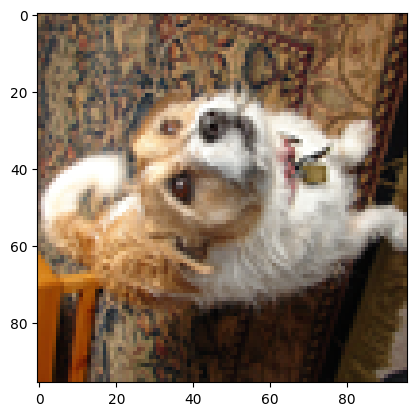

In [9]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n].transpose(1, 2, 0))

Let us now visualize the puzzle

In [10]:
a,b = test_gen.__getitem__(1)

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


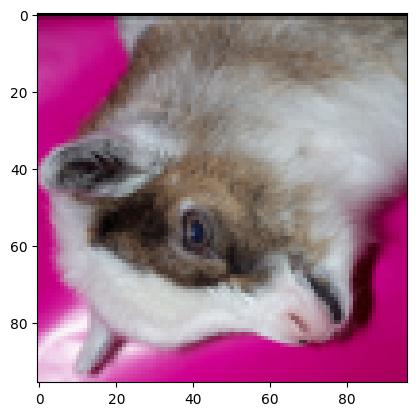

In [12]:
plt.imshow(b[4])

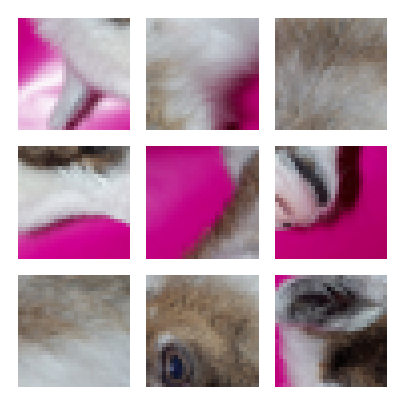

In [13]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [14]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [15]:
#compute MAE for mean_patch_image using the test_gen
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_gen)):
    a,b = test_gen.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.1822178, shape=(), dtype=float32)
std: tf.Tensor(0.0014526012, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





## Data Generator with Augmentation

The base `PatchGenerator` handles patch extraction but applies no augmentation. Here we extend it with `PuzzleGen`, which applies random brightness, contrast, color jitter and horizontal flips to the **full image before slicing** — this is critical. If augmentation were applied per-patch independently, the color statistics across patches would be inconsistent, making edge-matching impossible for the solver.

The generator also returns the ground-truth permutation `PERM` alongside the image target, which is needed to supervise the solver with a classification loss.


In [16]:
import numpy as np

class PuzzleGen(PatchGenerator):
    def __init__(self, *a, augment=False, **kw):
        super().__init__(*a, **kw)
        self.augment = augment

    def _aug(self, img):
        # brightness ±0.15, contrast 0.85-1.15, hue shift via channel scale
        if np.random.rand() < 0.8:
            img = img * np.random.uniform(0.85, 1.15)
            img = img + np.random.uniform(-0.10, 0.10)
            # per-channel gain (mild color jitter)
            g = np.random.uniform(0.92, 1.08, size=(1,1,3)).astype("float32")
            img = img * g
            img = np.clip(img, 0.0, 1.0)
        # horizontal flip (whole image, keeps geometry valid)
        if np.random.rand() < 0.5:
            img = img[:, ::-1, :].copy()
        return img.astype("float32")

    def __getitem__(self, idx):
        bi = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        B = len(bi)
        ps, cs = self.patch_size, self.crop_size
        margin = (ps - cs) // 2
        X    = np.zeros((B, 9, cs, cs, 3), dtype="float32")
        Y    = np.zeros((B, 96, 96, 3),    dtype="float32")
        PERM = np.zeros((B, 9),            dtype="int32")

        for i, img_idx in enumerate(bi):
            full = self.images[img_idx].transpose(1,2,0).astype("float32")/255.0
            if self.augment:
                full = self._aug(full)
            Y[i] = full
            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r*ps, c*ps
                    p = full[y_s:y_s+ps, x_s:x_s+ps, :][margin:margin+cs,
                                                        margin:margin+cs, :]
                    patches.append(p)
            order = np.random.permutation(9)
            for slot, gpos in enumerate(order):
                X[i, slot]    = patches[gpos]
                PERM[i, slot] = gpos
        return X, {"image": Y, "perm": PERM}

EMBED_DIM = 192

train_gen2 = PuzzleGen(train_images, batch_size=64, shuffle=True,  augment=True)
val_gen2   = PuzzleGen(val_images,   batch_size=64, shuffle=False, augment=False)
test_gen2  = PuzzleGen(test_images,  batch_size=64, shuffle=False, augment=False)

print("PuzzleGen v2 ready (augment=True for train).")
_Xs, _t = train_gen2.__getitem__(0)
print("X:", _Xs.shape, "image:", _t['image'].shape, "perm:", _t['perm'].shape)

PuzzleGen v2 ready (augment=True for train).
X: (64, 9, 28, 28, 3) image: (64, 96, 96, 3) perm: (64, 9)


## Patch Encoder and Permutation Solver

The solver is responsible for predicting the correct spatial ordering of the 9 scrambled patches.

**Patch Encoder** — each 28×28 patch is encoded into 5 tokens:
- 1 **global token**: captures the overall patch appearance via average + max pooling
- 4 **edge tokens** (top, right, bottom, left): extracted from the border rows/columns of the feature map, so the model can reason about which edges should be adjacent

**Transformer Solver** — the 45 tokens (9 patches × 5) are passed through 6 Transformer blocks with multi-head attention. This lets every patch attend to every other patch and learn which edges are compatible neighbors.

**Sinkhorn Normalization** — the raw assignment logits are normalized into a doubly-stochastic matrix (rows and columns each sum to 1), which acts as a soft permutation. This is differentiable and allows end-to-end training with a cross-entropy loss on the permutation.


In [17]:

import keras
from keras import layers, models
import tensorflow as tf

def build_patch_encoder_edges(embed_dim=192):
    """Encode a 28x28 patch → (5, embed_dim): [global, top, right, bottom, left]."""
    inp = layers.Input(shape=(28,28,3))
    x = layers.Conv2D(64,3,padding='same',use_bias=False)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(64,3,padding='same',use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)  # 28x28x64
    x = layers.MaxPooling2D(2)(x)                                          # 14x14x64

    x = layers.Conv2D(128,3,padding='same',use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.DepthwiseConv2D(3,padding='same',use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(128,1,use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)  # 14x14x128

    x = layers.MaxPooling2D(2)(x)                                          # 7x7x128
    x = layers.Conv2D(192,3,padding='same',use_bias=False)(x)
    x = layers.BatchNormalization()(x); feat = layers.Activation('relu')(x)  # 7x7x192

    gap = layers.GlobalAveragePooling2D()(feat)
    gmp = layers.GlobalMaxPooling2D()(feat)
    glob = layers.Dense(embed_dim, activation='relu')(
        layers.Concatenate()([gap, gmp]))                       # (embed,)

    # ── edge tokens: pool the 1st/last row/col of feature map ──
    def edge_tok(slc, name):
        v = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1 if 'h' in name else 2))(slc)
        v = layers.Dense(embed_dim, activation='relu')(v)
        return v
    top    = layers.Lambda(lambda t: t[:, :1, :, :])(feat)        # (B,1,7,192)
    bot    = layers.Lambda(lambda t: t[:, -1:, :, :])(feat)
    left   = layers.Lambda(lambda t: t[:, :, :1, :])(feat)
    right  = layers.Lambda(lambda t: t[:, :, -1:, :])(feat)
    top_t  = layers.Dense(embed_dim, activation='relu')(layers.Flatten()(top))
    bot_t  = layers.Dense(embed_dim, activation='relu')(layers.Flatten()(bot))
    lef_t  = layers.Dense(embed_dim, activation='relu')(layers.Flatten()(left))
    rig_t  = layers.Dense(embed_dim, activation='relu')(layers.Flatten()(right))

    # stack 5 tokens per patch
    out = layers.Lambda(lambda ts: tf.stack(ts, axis=1))(
        [glob, top_t, rig_t, bot_t, lef_t])                      # (B,5,embed)
    return models.Model(inp, out, name='patch_encoder_edges')

@keras.saving.register_keras_serializable()
class TokenTypeAndPosEmbedding(layers.Layer):
    """Adds learnable embeddings for (slot 0..8) and (token type 0..4)."""
    def __init__(self, num_slots=9, num_types=5, embed_dim=192, **kw):
        super().__init__(**kw)
        self.num_slots = num_slots; self.num_types = num_types
        self.embed_dim = embed_dim
        self.slot_emb = layers.Embedding(num_slots, embed_dim)
        self.type_emb = layers.Embedding(num_types, embed_dim)
    def build(self, s):
        self.slot_emb.build((None,)); self.type_emb.build((None,))
        super().build(s)
    def call(self, x):
        # x: (B, 9, 5, D)
        s = self.slot_emb(tf.range(self.num_slots))[None,:,None,:]   # (1,9,1,D)
        t = self.type_emb(tf.range(self.num_types))[None,None,:,:]   # (1,1,5,D)
        return x + s + t
    def get_config(self):
        c=super().get_config()
        c.update({'num_slots':self.num_slots,'num_types':self.num_types,
                  'embed_dim':self.embed_dim})
        return c

@keras.saving.register_keras_serializable()
class Sinkhorn(layers.Layer):
    """Sinkhorn normalization → doubly-stochastic 9x9 matrix."""
    def __init__(self, n_iter=10, tau=1.0, **kw):
        super().__init__(**kw); self.n_iter=n_iter; self.tau=tau
    def call(self, logits):
        x = logits / self.tau
        for _ in range(self.n_iter):
            x = x - tf.reduce_logsumexp(x, axis=-1, keepdims=True)   # row-norm
            x = x - tf.reduce_logsumexp(x, axis=-2, keepdims=True)   # col-norm
        return tf.exp(x)   # (B,9,9), nearly doubly-stochastic
    def get_config(self):
        c=super().get_config(); c.update({'n_iter':self.n_iter,'tau':self.tau})
        return c

def build_solver(embed_dim=192, num_heads=6, ff_dim=512, n_blocks=6):
    pin = layers.Input(shape=(9,28,28,3), name='patches_input')
    enc = build_patch_encoder_edges(embed_dim)
    tokens = layers.TimeDistributed(enc)(pin)                  # (B,9,5,D)
    tokens = TokenTypeAndPosEmbedding(9, 5, embed_dim)(tokens)
    x = layers.Reshape((45, embed_dim))(tokens)                # (B,45,D)

    for i in range(n_blocks):
        a = layers.MultiHeadAttention(num_heads, embed_dim//num_heads,
                                      dropout=0.1)(x, x)
        x = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, a]))
        f = layers.Dense(ff_dim, activation='gelu')(x)
        f = layers.Dropout(0.1)(f)
        f = layers.Dense(embed_dim)(f)
        x = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, f]))

    # Take only the GLOBAL token (type 0) per slot for assignment
    x = layers.Reshape((9, 5, embed_dim))(x)
    slot_feat = layers.Lambda(lambda t: t[:, :, 0, :])(x)      # (B,9,D)
    logits = layers.Dense(9, name='assign_logits')(slot_feat)  # (B,9,9)
    probs  = Sinkhorn(n_iter=10, tau=1.0, name='sinkhorn')(logits)
    return models.Model(pin, [logits, probs], name='solver')

solver = build_solver(EMBED_DIM)
print(f"Solver params: {solver.count_params():,}")

Solver params: 3,542,985


## Spatial Assembler — Placing Patches onto the Canvas

Once the solver produces a soft permutation matrix, we need to physically reconstruct the image. The `PlacePatches` layer does this in a fully differentiable way — no Python loops at inference time.

The key idea is a **soft patch reordering**: instead of hard-assigning each patch to a grid position (which would be non-differentiable), we use the Sinkhorn probability matrix to compute a weighted blend of all patches for each grid slot. During training this is a smooth mixture; as the solver improves, the weights sharpen toward a one-hot assignment.

After reordering, patches are placed onto a 96×96 canvas at their correct grid positions (with a 2-pixel margin on each side from the erosion). A binary mask is returned alongside the canvas to tell the refiner exactly which pixels are missing and need to be inpainted.


In [18]:
@keras.saving.register_keras_serializable()
class PlacePatches(layers.Layer):
    def __init__(self, **kw):
        super().__init__(**kw)
        # Static (96,96) index maps: for each pixel → grid cell + local coord
        coords = np.full((96,96), -1, dtype=np.int32)
        ly     = np.zeros((96,96), dtype=np.int32)
        lx     = np.zeros((96,96), dtype=np.int32)
        for r in range(3):
            for c in range(3):
                g = r*3+c
                y0, x0 = r*32+2, c*32+2
                for dy in range(28):
                    for dx in range(28):
                        coords[y0+dy, x0+dx] = g
                        ly[y0+dy, x0+dx]     = dy
                        lx[y0+dy, x0+dx]     = dx

        # Flatten to 1D lookup vectors (9216 pixels)
        self.cidx  = tf.constant(coords.flatten())          # (9216,)
        self.lyf   = tf.constant(ly.flatten())              # (9216,)
        self.lxf   = tf.constant(lx.flatten())              # (9216,)

        # Valid mask: 1 where a patch covers, 0 in border gaps
        valid = (coords.flatten() >= 0).astype(np.float32)
        self.valid = tf.constant(valid[None, :, None])      # (1,9216,1)

    def call(self, inputs):
        patches, probs = inputs     # (B,9,28,28,3), (B,9slot,9grid)
        B = tf.shape(patches)[0]

        # ── Step 1: compute grid-ordered patches via soft permutation ──
        # probs: (B, slot, grid) → transpose → (B, grid, slot)
        pg   = tf.transpose(probs, [0, 2, 1])               # (B, 9, 9)
        flat = tf.reshape(patches, [B, 9, 28*28*3])         # (B, 9, 2352)
        # (B, 9grid, 9slot) × (B, 9slot, 2352) → (B, 9grid, 2352)
        gridp = tf.matmul(pg, flat)
        gridp = tf.reshape(gridp, [B, 9, 28, 28, 3])        # (B,9,28,28,3)

        # ── Step 2: vectorized pixel gather (NO map_fn) ───────────────
        # Build batch indices: (B, 9216)
        cidx_safe = tf.maximum(self.cidx, 0)                # clamp -1 → 0
        B_idx = tf.repeat(
            tf.range(B)[:, None], 9216, axis=1
        )                                                    # (B, 9216)

        # Broadcast lookup indices to full batch
        g_idx = tf.broadcast_to(cidx_safe[None, :], [B, 9216])  # (B,9216)
        y_idx = tf.broadcast_to(self.lyf[None, :],  [B, 9216])  # (B,9216)
        x_idx = tf.broadcast_to(self.lxf[None, :],  [B, 9216])  # (B,9216)

        # Stack into gather indices: (B, 9216, 4)
        gather_idx = tf.stack([B_idx, g_idx, y_idx, x_idx], axis=-1)

        # Single GPU gather — fully parallel, no Python loop
        pix = tf.gather_nd(gridp, gather_idx)               # (B, 9216, 3)

        # ── Step 3: apply valid mask and reshape to canvas ────────────
        pix    = pix * self.valid                            # zero out gaps
        canvas = tf.reshape(pix, [B, 96, 96, 3])

        # Broadcast mask to full batch
        mask = tf.broadcast_to(self.valid, [B, 9216, 1])
        mask = tf.reshape(mask, [B, 96, 96, 1])

        return canvas, mask

    def get_config(self):
        return super().get_config()

## Image Refiner and Full Pipeline

**Refiner** — a lightweight U-Net that takes the assembled canvas (plus the gap mask as a 4th channel) and produces a clean 96×96 reconstruction. The encoder progressively compresses spatial resolution while building rich feature representations; the decoder mirrors this with skip connections that preserve fine detail. The mask channel tells the network exactly where the border gaps are, so it can focus its inpainting capacity there rather than wasting capacity on pixels that are already correct.

**JigsawPipeline** — wraps the solver, placer and refiner into a single trainable model. The final output blends the raw canvas (where patches exist) with the refiner output (where gaps are), so the network only needs to learn to fill what is missing.

The training loss combines two terms:
- **MAE** on the reconstructed image — the primary evaluation metric
- **Label-smoothed cross-entropy** on the predicted permutation — guides the solver to learn correct patch ordering

The permutation loss weight `lambda_perm` is annealed across three training phases to shift focus from ordering accuracy early on toward pixel-level reconstruction quality later.


In [19]:

def cb(x, f, p):
    x = layers.Conv2D(f,3,padding='same',use_bias=False,name=f'{p}_a')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(f,3,padding='same',use_bias=False,name=f'{p}_b')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    return x

def build_refiner():
    inp = layers.Input(shape=(96,96,4), name='refiner_in')
    e0 = cb(inp, 32, 'r_e0')
    e1 = cb(layers.MaxPooling2D(2)(e0), 64, 'r_e1')
    e2 = cb(layers.MaxPooling2D(2)(e1), 96, 'r_e2')
    b  = cb(layers.MaxPooling2D(2)(e2), 128,'r_b')
    d2 = layers.UpSampling2D(2,interpolation='bilinear')(b)
    d2 = cb(layers.Concatenate()([d2,e2]), 96, 'r_d2')
    d1 = layers.UpSampling2D(2,interpolation='bilinear')(d2)
    d1 = cb(layers.Concatenate()([d1,e1]), 64, 'r_d1')
    d0 = layers.UpSampling2D(2,interpolation='bilinear')(d1)
    d0 = cb(layers.Concatenate()([d0,e0]), 32, 'r_d0')
    out = layers.Conv2D(3,1,activation='sigmoid',name='refine_rgb')(d0)
    return models.Model(inp, out, name='refiner')

refiner = build_refiner()
print(f"Refiner params: {refiner.count_params():,}")


# FULL PIPELINE — uses Sinkhorn probs for placement, raw logits for CE

@keras.saving.register_keras_serializable()
class JigsawPipeline(keras.Model):
    def __init__(self, solver, refiner, lambda_perm=5.0,
                 label_smoothing=0.05, **kw):
        super().__init__(**kw)
        self.solver=solver; self.placer=PlacePatches(); self.refiner=refiner
        self.lambda_perm=lambda_perm
        self.ls=label_smoothing
        self.mae_t  = keras.metrics.Mean(name='mae')
        self.acc_t  = keras.metrics.Mean(name='perm_acc')
        self.loss_t = keras.metrics.Mean(name='loss')

    def call(self, x, training=False):
        logits, probs = self.solver(x, training=training)   # (B,9,9), (B,9,9)
        canvas, mask  = self.placer([x, probs])
        ref_in        = tf.concat([canvas, mask], -1)
        pred          = self.refiner(ref_in, training=training)
        out           = canvas*mask + pred*(1.0-mask)
        return out, logits, probs

    def _compute(self, x, y, training):
        img  = y['image']; perm = y['perm']
        out, logits, _ = self(x, training=training)
        mae = tf.reduce_mean(tf.abs(img - out))
        # label-smoothed CE
        oh = tf.one_hot(perm, 9)
        oh = oh*(1.0-self.ls) + self.ls/9.0
        ce = tf.reduce_mean(
            keras.losses.categorical_crossentropy(oh, logits, from_logits=True))
        loss = mae + self.lambda_perm*ce
        acc  = tf.reduce_mean(tf.cast(
            tf.argmax(logits,-1,output_type=tf.int32)==perm, tf.float32))
        return loss, mae, acc

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            loss, mae, acc = self._compute(x, y, True)
        g = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(g, self.trainable_variables))
        self.loss_t.update_state(loss); self.mae_t.update_state(mae)
        self.acc_t.update_state(acc)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        loss, mae, acc = self._compute(x, y, False)
        self.loss_t.update_state(loss); self.mae_t.update_state(mae)
        self.acc_t.update_state(acc)
        return {m.name: m.result() for m in self.metrics}

    @property
    def metrics(self): return [self.loss_t, self.mae_t, self.acc_t]

pipeline = JigsawPipeline(solver, refiner, lambda_perm=5.0, label_smoothing=0.05)
_ = pipeline(_Xs[:2])
total = solver.count_params() + refiner.count_params()
print(f"TOTAL params: {total:,}  ({'OK ✅' if total<6_000_000 else 'OVER ❌'})")

Refiner params: 908,515
TOTAL params: 4,451,500  (OK ✅)


## Training Schedule

Training is split into three phases, each with a different permutation loss weight and learning rate. This curriculum lets the model first focus on getting the patch ordering right, then gradually shift attention toward pixel-level reconstruction quality.

| Phase | Epochs | `lambda_perm` | Peak LR | Purpose |
|-------|--------|---------------|---------|---------|
| 1 | 15 | 10.0 | 6e-4 | Learn coarse patch ordering |
| 2 | 20 | 3.0 | 3e-4 | Balance ordering and reconstruction |
| 3 | 15 | 1.0 | 1e-4 | Fine-tune reconstruction quality |

Each phase uses a cosine decay schedule with a short linear warmup. The best weights (by validation MAE) are saved automatically via a checkpoint callback.

Set `TRAIN_MODEL = False` to skip training and load pre-trained weights directly from Google Drive.


In [20]:

TRAIN_MODEL = False  # ← SET TO FALSE TO LOAD FROM GDRIVE
WEIGHTS_PATH = '/content/best_pipeline.weights.h5'
GDRIVE_URL   = 'https://drive.google.com/uc?id=15CXX7y6HgT0zzowz9waQsmcwvcF3YEv_'

if TRAIN_MODEL:
    ckpt = keras.callbacks.ModelCheckpoint(
        WEIGHTS_PATH,
        monitor='val_mae', mode='min',
        save_best_only=True, save_weights_only=True, verbose=1)
    csv = keras.callbacks.CSVLogger('/content/training_log.csv', append=True)

    def make_lr(epochs, lr_peak):
        steps = epochs*len(train_gen2)
        return keras.optimizers.schedules.CosineDecay(
            1e-6, steps, alpha=5e-2,
            warmup_steps=int(0.05*steps), warmup_target=lr_peak)

    # ---- Phase 1 ----
    pipeline.lambda_perm = 10.0
    pipeline.compile(optimizer=keras.optimizers.AdamW(
        make_lr(15, 6e-4), weight_decay=1e-5, clipnorm=1.0))
    pipeline.fit(train_gen2, validation_data=val_gen2,
                 epochs=15, callbacks=[ckpt, csv], verbose=1)

    # ---- Phase 2 ----
    pipeline.lambda_perm = 3.0
    pipeline.compile(optimizer=keras.optimizers.AdamW(
        make_lr(20, 3e-4), weight_decay=1e-5, clipnorm=1.0))
    pipeline.fit(train_gen2, validation_data=val_gen2,
                 epochs=20, callbacks=[ckpt, csv], verbose=1)

    # ---- Phase 3 ----
    pipeline.lambda_perm = 1.0
    pipeline.compile(optimizer=keras.optimizers.AdamW(
        make_lr(15, 1e-4), weight_decay=1e-5, clipnorm=1.0))
    pipeline.fit(train_gen2, validation_data=val_gen2,
                 epochs=15, callbacks=[ckpt, csv], verbose=1)

    print("Done.")

else:
    import gdown
    print("⏭️  Loading weights from GDrive...")
    gdown.download(GDRIVE_URL, WEIGHTS_PATH, quiet=False, fuzzy=True)
    pipeline.load_weights(WEIGHTS_PATH)
    print("✅ Weights loaded!")


⏭️  Loading weights from GDrive...


Downloading...
From: https://drive.google.com/uc?id=15CXX7y6HgT0zzowz9waQsmcwvcF3YEv_
To: /content/best_pipeline.weights.h5
100%|██████████| 54.0M/54.0M [00:00<00:00, 102MB/s]


✅ Weights loaded!


## Evaluation

We evaluate the trained pipeline on the held-out test set (10,000 images). For each batch we run a forward pass, compute per-batch MAE against the ground truth, and track permutation accuracy to confirm the solver is placing patches correctly.

We then visualize a few examples side by side:
- **Scrambled** — the input patches placed in their given (wrong) order
- **Reconstruction** — the pipeline's output
- **Ground Truth** — the original image
- **Error ×3** — absolute pixel error amplified 3× to make differences visible


MAE: 0.028679659590125084
std: 0.0005836104974150658


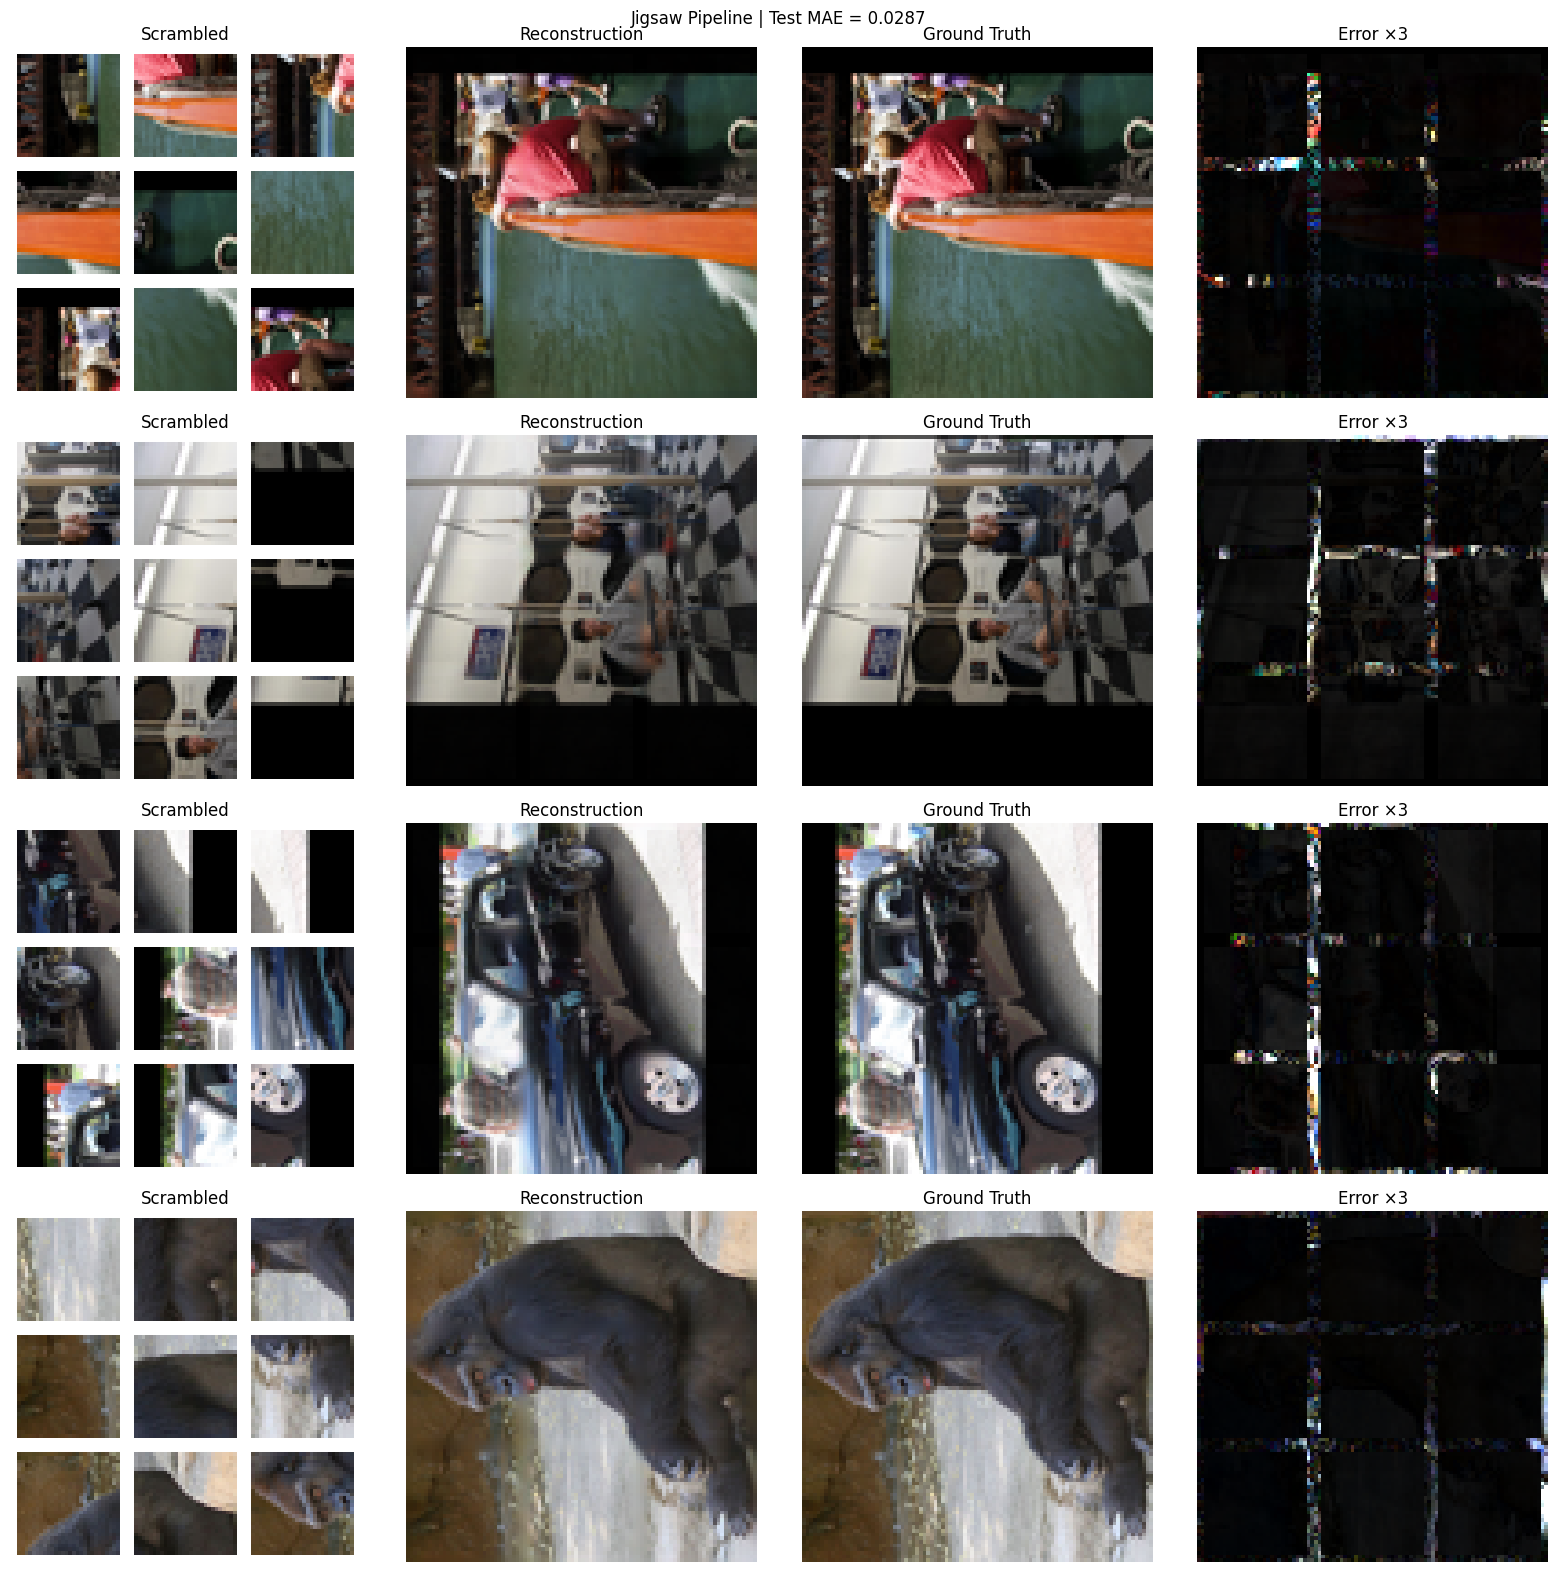

In [23]:
# load best weights (already loaded above if TRAIN_MODEL=False)
if TRAIN_MODEL:
    pipeline.load_weights(WEIGHTS_PATH)

# evaluate MAE — same pattern as the baseline cell
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []

for i in range(len(test_gen2)):
    Xb, tb = test_gen2.__getitem__(i)
    out = pipeline(Xb, training=False)[0]
    mae_values.append(mae(out, tb['image']))

test_mae = float(tf.reduce_mean(mae_values))
print("MAE:", test_mae)
print("std:", float(tf.math.reduce_std(mae_values)))

#visualization
import matplotlib.pyplot as plt
def visualize(n=4):
    g = PuzzleGen(test_images[:n], batch_size=n, shuffle=False)
    Xb, tb = g.__getitem__(0)
    outputs = pipeline(Xb, training=False)
    out = np.array(outputs[0])                  # safe unpack
    cols = ['Scrambled', 'Reconstruction', 'Ground Truth', 'Error ×3']
    fig, ax = plt.subplots(n, 4, figsize=(16, 4*n))
    for i in range(n):
        cv = np.ones((96, 96, 3), 'float32')
        for s in range(9):
            r, c = s//3, s%3
            cv[r*32+2:r*32+30, c*32+2:c*32+30] = Xb[i, s]
        diff = np.abs(tb['image'][i] - out[i])
        for j, im in enumerate([cv, out[i], tb['image'][i], np.clip(diff*3, 0, 1)]):
            ax[i, j].imshow(np.clip(im, 0, 1))
            ax[i, j].set_title(cols[j])
            ax[i, j].axis('off')
    plt.suptitle(f'Jigsaw Pipeline | Test MAE = {test_mae:.4f}')
    plt.tight_layout()
    plt.savefig('reconstruction_results.png', dpi=150)
    plt.show()

visualize(4)
